<a href="https://colab.research.google.com/github/epashkeeva-ui/project_p/blob/%D0%9A%D1%83%D0%BF%D1%87%D0%B0-%D0%A1%D0%BE%D1%84%D1%8C%D1%8F/project_version_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
#адреса складов
#Полярная ул., 27 корп4, Москва, Россия, 127081
#Рязанский пр., 4а, Москва, Россия, 142800


In [22]:
import requests
import time
import re
import pandas as pd
from bs4 import BeautifulSoup
from urllib.parse import urljoin

YANDEX_GEOCODER_KEY = ""

BASE_URL    = "https://holodmoroz.ru"
LISTING_URL = "https://holodmoroz.ru/arenda"

HEADERS = {"User-Agent": "Mozilla/5.0"}


In [23]:
LISTING = "https://moskva.skladoiskatel.ru/moskva/holodilnye-i-morozilnye-sklady/"

response = requests.get(LISTING, headers=HEADERS)
links = re.findall(r"/sklady-ot-sobstvennikov/\d+-[a-z0-9\-]+/", response.text)
links = list(set(links))

print(f"Найдено ссылок: {len(links)}")

Найдено ссылок: 30


In [40]:
sklado_records = []

for i, link in enumerate(links, 1):
    url = "https://moskva.skladoiskatel.ru" + link
    html = requests.get(url, headers=HEADERS).text
    soup = BeautifulSoup(html, "html.parser")

    obj_id = re.search(r"/(\d+)-", url).group(1)
    address = soup.find("div", class_="b-place").find("address").get_text(strip=True)
    price_text = soup.find("div", class_="b-meta").get_text()

    price_match = re.search(r"([\d\s,]+)\s*руб", price_text)
    if price_match:
        digits = price_match.group(1).replace(" ", "").split(",")[0]
        price = int(digits) if digits else None
    else:
        price = None

    # На сайте перепутаны имена: 'long' = широта, 'lat' = долгота
    lat_match = re.search(r"'long':\s*([\d.]+)", html)
    lon_match = re.search(r"'lat':\s*([\d.]+)", html)
    lat = float(lat_match.group(1)) if lat_match else None
    lon = float(lon_match.group(1)) if lon_match else None

    sklado_records.append({
        "id": obj_id,
        "address": address,
        "price": price,
        "latitude": lat,
        "longitude": lon,
    })
    time.sleep(0.3)

df_sklado = pd.DataFrame(sklado_records)
df_sklado

,id,address,price,latitude,longitude
0,144407,"Москва, Кавказский бульвар 57 с3 ( Район...",1000.0,55.627905,37.635278
1,149517,"Москва, ул. Плеханова, д.15 ( Район: Юг...",1089.0,55.749790,37.763962
2,114733,"Москва, Коровинское шоссе ( Район: Север...",983.0,55.885531,37.514870
3,117826,"Москва, ул. Новохохловская ( Район: Вост...",487.0,55.730332,37.707723
4,121855,"Москва, Алтуфьевское шоссе ( Район: Севе...",710.0,55.864987,37.581679
5,107448,"Москва, Котляковский 2-й пер., д.1. ( Ра...",381.0,55.648926,37.630894
6,170003,"Москва, 2-ая вольская 30с27 ( Район: Юго...",1100.0,55.688380,37.939106
7,159233,"Москва, 1 ый рижский переулок д 2 с 3 ...",3000.0,55.809504,37.654044
8,114745,"Москва, ул.Деловая ( Район: Южный)",700.0,55.622301,37.634004
9,154948,"Москва, Коровинское шоссе 35с15 ( Район:...",1200.0,55.883045,37.516197


In [41]:
df_sklado_simple = df_sklado[["id", "price", "latitude", "longitude"]]
df_sklado_simple

,id,price,latitude,longitude
0,144407,1000.0,55.627905,37.635278
1,149517,1089.0,55.749790,37.763962
2,114733,983.0,55.885531,37.514870
3,117826,487.0,55.730332,37.707723
4,121855,710.0,55.864987,37.581679
5,107448,381.0,55.648926,37.630894
6,170003,1100.0,55.688380,37.939106
7,159233,3000.0,55.809504,37.654044
8,114745,700.0,55.622301,37.634004
9,154948,1200.0,55.883045,37.516197


In [42]:
TWO_GIS_KEY = ""

In [43]:
results = []

#берем 10 страниц, у 2гис лимит pagesize 10, итого 100 точек покрывает наши найденные 50
for page in range(1, 11):
    response = requests.get(
        "https://catalog.api.2gis.com/3.0/items",
        params={
            "q": "Ozon Fresh",
            "region_id": 32,
            "fields": "items.point,items.address,items.name",
            "page_size": 10,
            "page": page,
            "key": TWO_GIS_KEY,
        }
    )

    items = response.json().get("result", {}).get("items", [])
    if not items:
        break

    for item in items:
        if "ozon" not in item.get("name", "").lower():
            continue

        point = item.get("point", {})
        results.append({
            "name": item["name"],
            "address": item.get("address_name", ""),
            "latitude": point["lat"],
            "longitude": point["lon"],
        })

    time.sleep(0.3)

df_ozon = pd.DataFrame(results).drop_duplicates(subset=["address"])
print(f"Найдено точек Ozon: {len(df_ozon)}")
df_ozon

Найдено точек Ozon: 50


,name,address,latitude,longitude
0,"Ozon fresh, склад","Молодогвардейская улица, 61 ст20",55.732148,37.394040
1,"Ozon fresh, служба доставки продуктов","Индустриальная улица, 3",55.481486,37.311420
2,"Ozon fresh, служба доставки продуктов","Шарикоподшипниковская улица, 13 ст46",55.721584,37.684243
3,"Ozon fresh, служба доставки продуктов","Полевая улица, 19",55.660230,37.252642
4,"Ozon fresh, служба доставки продуктов","проспект Мира, 211",55.846172,37.659945
5,"Ozon fresh, служба доставки продуктов","Дмитровское шоссе, 131 к1",55.888731,37.541583
6,"Ozon fresh, служба доставки продуктов","Волгоградский проспект, 1 ст1",55.733733,37.670624
7,"Ozon fresh, служба доставки продуктов","Нагатинская набережная, 34",55.685007,37.669808
8,"Ozon fresh, служба доставки продуктов","улица Свободы, 20",55.833068,37.454068
9,"Ozon fresh, служба доставки продуктов","Скандинавский бульвар, 7",55.564607,37.502581


score = wprice ⋅ (price−pricemin) / (pricemax − pricemin) + wdist ⋅ (dist − distmin) / (distmax − distmin)

wprice = wdist = 0.5

In [44]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))


# Для каждого склада считаем расстояние до каждого ozon и берём минимум
distances = []

for _, sklado in df_sklado_simple.iterrows():
    all_distances = []
    for _, ozon in df_ozon.iterrows():
        d = haversine(
            sklado["latitude"], sklado["longitude"],
            ozon["latitude"], ozon["longitude"]
        )
        all_distances.append(d)

    # Минимальное — это ближайший Ozon
    distances.append(min(all_distances))

df_sklado_simple["distance_km"] = distances
df_sklado_simple

,id,price,latitude,longitude,distance_km
0,144407,1000.0,55.627905,37.635278,1.493055
1,149517,1089.0,55.749790,37.763962,3.646628
2,114733,983.0,55.885531,37.514870,0.490805
3,117826,487.0,55.730332,37.707723,1.762944
4,121855,710.0,55.864987,37.581679,1.934641
5,107448,381.0,55.648926,37.630894,1.667354
6,170003,1100.0,55.688380,37.939106,3.126502
7,159233,3000.0,55.809504,37.654044,2.701448
8,114745,700.0,55.622301,37.634004,1.433343
9,154948,1200.0,55.883045,37.516197,0.261447


In [45]:
w_price = 0.5
w_dist = 0.5

df_score = df_sklado_simple.dropna(subset=["price"]).copy()
df_score = df_score[df_score["price"] > 0]

price_min = df_score["price"].min()
price_max = df_score["price"].max()
df_score["price_norm"] = (df_score["price"] - price_min) / (price_max - price_min)

dist_min = df_score["distance_km"].min()
dist_max = df_score["distance_km"].max()
df_score["dist_norm"] = (df_score["distance_km"] - dist_min) / (dist_max - dist_min)

df_score["score"] = w_price * df_score["price_norm"] + w_dist * df_score["dist_norm"]

df_score = df_score.sort_values("score")
df_score

,id,price,latitude,longitude,distance_km,price_norm,dist_norm,score
5,107448,381.0,55.648926,37.630894,1.667354,0.000000,0.034470,0.017235
20,117640,712.0,55.886267,37.500359,1.005223,0.018109,0.018236,0.018173
2,114733,983.0,55.885531,37.514870,0.490805,0.032936,0.005623,0.019280
3,117826,487.0,55.730332,37.707723,1.762944,0.005799,0.036814,0.021307
9,154948,1200.0,55.883045,37.516197,0.261447,0.044808,0.000000,0.022404
12,107540,900.0,55.731054,37.685620,0.985014,0.028395,0.017740,0.023068
8,114745,700.0,55.622301,37.634004,1.433343,0.017453,0.028733,0.023093
22,114425,890.0,55.880422,37.496883,1.050287,0.027848,0.019341,0.023594
13,114430,508.0,55.744630,37.786240,2.174194,0.006948,0.046897,0.026923
21,137000,1000.0,55.693023,37.581379,1.094221,0.033866,0.020418,0.027142


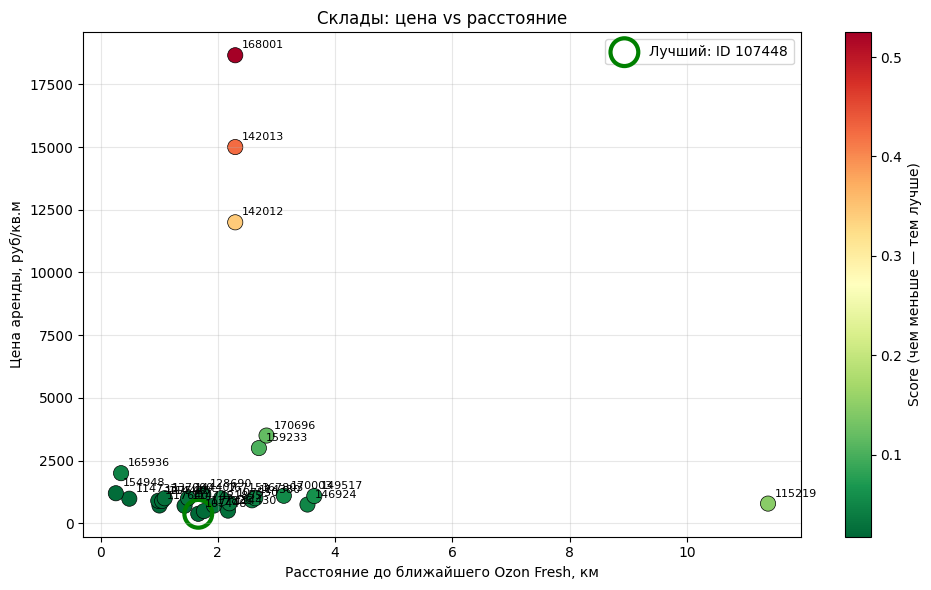

In [47]:
import matplotlib.pyplot as plt

# Это выброс
df_plot = df_score[df_score["id"] != "141157"]

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_plot["distance_km"],
    df_plot["price"],
    c=df_plot["score"],
    cmap="RdYlGn_r",
    s=120,
    edgecolor="black",
    linewidth=0.5,
)

for _, row in df_plot.iterrows():
    ax.annotate(
        row["id"],
        (row["distance_km"], row["price"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

best = df_plot.sort_values("score").iloc[0]
ax.scatter(
    best["distance_km"],
    best["price"],
    s=400,
    facecolor="none",
    edgecolor="green",
    linewidth=3,
    label=f"Лучший: ID {best['id']}",
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Score (чем меньше — тем лучше)")

ax.set_xlabel("Расстояние до ближайшего Ozon Fresh, км")
ax.set_ylabel("Цена аренды, руб/кв.м")
ax.set_title("Склады: цена vs расстояние")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [48]:
best = df_score.iloc[0]

print(f"Оптимальный склад: ID {best['id']}")
print(f"Цена {best['price']} руб/кв.м")
print(f"Расстояние {best['distance_km']:.2f} км до ближайшего Ozon Fresh")
print(f"Score {best['score']:.3f}")

Оптимальный склад: ID 107448
Цена 381.0 руб/кв.м
Расстояние 1.67 км до ближайшего Ozon Fresh
Score 0.017


In [49]:
df_sklado[df_sklado["id"] == best['id']]["address"].values[0]


'Москва, Котляковский 2-й пер., д.1.       ( Район: Южный)'

In [52]:
for link in links:
    if best['id'] in link:
        print("https://moskva.skladoiskatel.ru" + link)
        break

https://moskva.skladoiskatel.ru/sklady-ot-sobstvennikov/107448-zao-moskvoreckoe/
